In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import re

First we will load all percipitation data before loading all the discharge data. This will then be saved into dataframes for further analysis.

In [3]:
percipitation_black = pd.read_csv(r"precipitation data volta\mswep\Black Volta_-2.75_9.55.csv", index_col=0, parse_dates=True)
percipitation_lake = pd.read_csv(r"precipitation data volta\mswep\Lake Volta_0.05_6.45.csv", index_col=0, parse_dates=True)
percipitation_mouhoun = pd.read_csv(r"precipitation data volta\mswep\Mouhoun_-3.95_12.05.csv", index_col=0, parse_dates=True)
percipitation_nakambe = pd.read_csv(r"precipitation data volta\mswep\Nakambe_-2.15_13.55.csv", index_col=0, parse_dates=True)
percipitation_oti = pd.read_csv(r"precipitation data volta\mswep\Oti_0.15_8.45.csv", index_col=0, parse_dates=True)
percipitation_pendjari = pd.read_csv(r"precipitation data volta\mswep\Pendjari_1.15_11.15.csv", index_col=0, parse_dates=True)


Discharge Data:

This data is loaded first to see what is going on. It is then split into the 2 rivers which it measures, and plotted against time. Data is taken 3 times per month. 

In [4]:
discharge = pd.read_excel(r"discharge data volta\discharge in columns.xlsx")
discharge.head()

,MOU HO,UN (VO,LTA NO,IRE),Unnamed: 4,Unnamed: 5,SA,MANDEN,I,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,1 11977
1,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,2 11977
2,2,2,2,2,2.0,2.0,2,2,2.0,2.0,2.0,3 11977
3,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,1 21977
4,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,2 21977


In [7]:

path = r"discharge data volta\discharge in columns.xlsx"
raw = pd.read_excel(path, header=None)

def is_number(x):
    try:
        float(x)
        return True
    except Exception:
        return False

def join_tokens(row, cols):
    toks = [row[c] for c in cols if pd.notna(row[c])]
    s = " ".join(map(str, toks))
    s = re.sub(r"\s+", " ", s).strip()
    return s

records = []
cur_river = None
cur_station = None

for _, row in raw.iterrows():
    # Header rows: first cell is not numeric -> contains river/station fragments
    if not is_number(row[0]):
        cur_river = join_tokens(row, range(0, 6))   # cols 0-5
        cur_station = join_tokens(row, range(6, 11)) # cols 6-10
        continue

    meta = row[11]
    if pd.isna(meta) or cur_river is None:
        continue

    # meta like "2 21977" -> r=2, month=2, year=1977
    parts = str(meta).split()
    if len(parts) != 2:
        continue
    r = int(parts[0])
    my = int(parts[1])
    month = my // 10000
    year = my % 10000

    # values live in cols 0..10 (10 values for row 1/2, up to 11 for row 3)
    vals = pd.to_numeric(row.loc[0:10], errors="coerce").dropna().to_list()
    start_day = (r - 1) * 10 + 1

    for i, v in enumerate(vals):
        day = start_day + i
        # build date; invalid dates (e.g., Feb 30) become NaT and are skipped
        dt = pd.to_datetime({"year": [year], "month": [month], "day": [day]}, errors="coerce")[0]
        if pd.isna(dt):
            continue

        if v == 9999:
            v = np.nan

        records.append({
            "Date": dt,
            "River": cur_river,
            "Station": cur_station,
            "Row": r,
            "Discharge": v
        })

df = pd.DataFrame(records).set_index("Date").sort_index()

# One dataframe per river (each retains Station/Row/Discharge as columns)
river_dfs = {riv: g.copy() for riv, g in df.groupby("River")}



['BOUGOU RIBA', 'MOU HO UN (VO LTA NO IRE)', 'NAKANB E (VOL TA BLA NCHE)', 'NAZINO N (VOL TA ROU GE)', 'PENDJA RI', 'SINGOU', 'VOLTA NOIRE']


In [8]:
river_names = list(river_dfs.keys())[:]
print(river_names)
df_river1, df_river2, df_river3 = (river_dfs[river_names[0]], river_dfs[river_names[1]], river_dfs[river_names[2]])

['BOUGOU RIBA', 'MOU HO UN (VO LTA NO IRE)', 'NAKANB E (VOL TA BLA NCHE)', 'NAZINO N (VOL TA ROU GE)', 'PENDJA RI', 'SINGOU', 'VOLTA NOIRE']


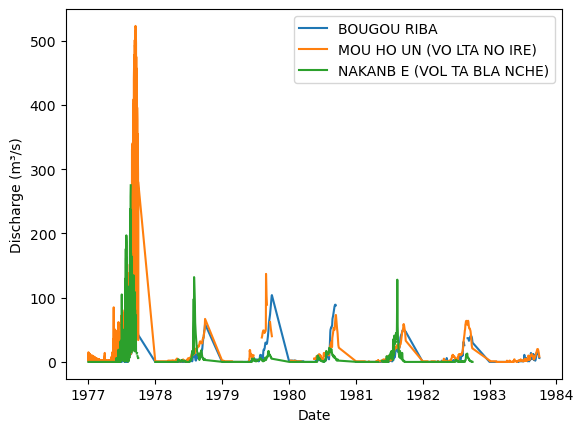

In [9]:
plt.plot(df_river1.index, df_river1["Discharge"], label=river_names[0])
plt.plot(df_river2.index, df_river2["Discharge"], label=river_names[1])
plt.plot(df_river3.index, df_river3["Discharge"], label=river_names[2])
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.show()